# Tarefa 1 Análise de Clusters com K-means

**Aluno:** Cauê Reis  
**Disciplina:** Aprendizado de Máquina Não Supervisionado  

## Parte 1 – Clusterização com K-Means em Dados Sintéticos (make_blobs)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)
print("Shape dos dados:", X.shape)

Shape dos dados: (300, 2)


### a) Visualização dos dados originais

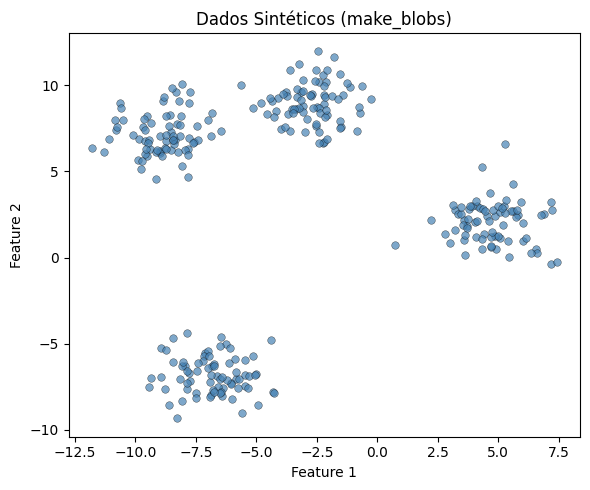

In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.3)
plt.title("Dados Sintéticos (make_blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

### b) Aplicação do K-Means para k = 2, 3, 4, 5

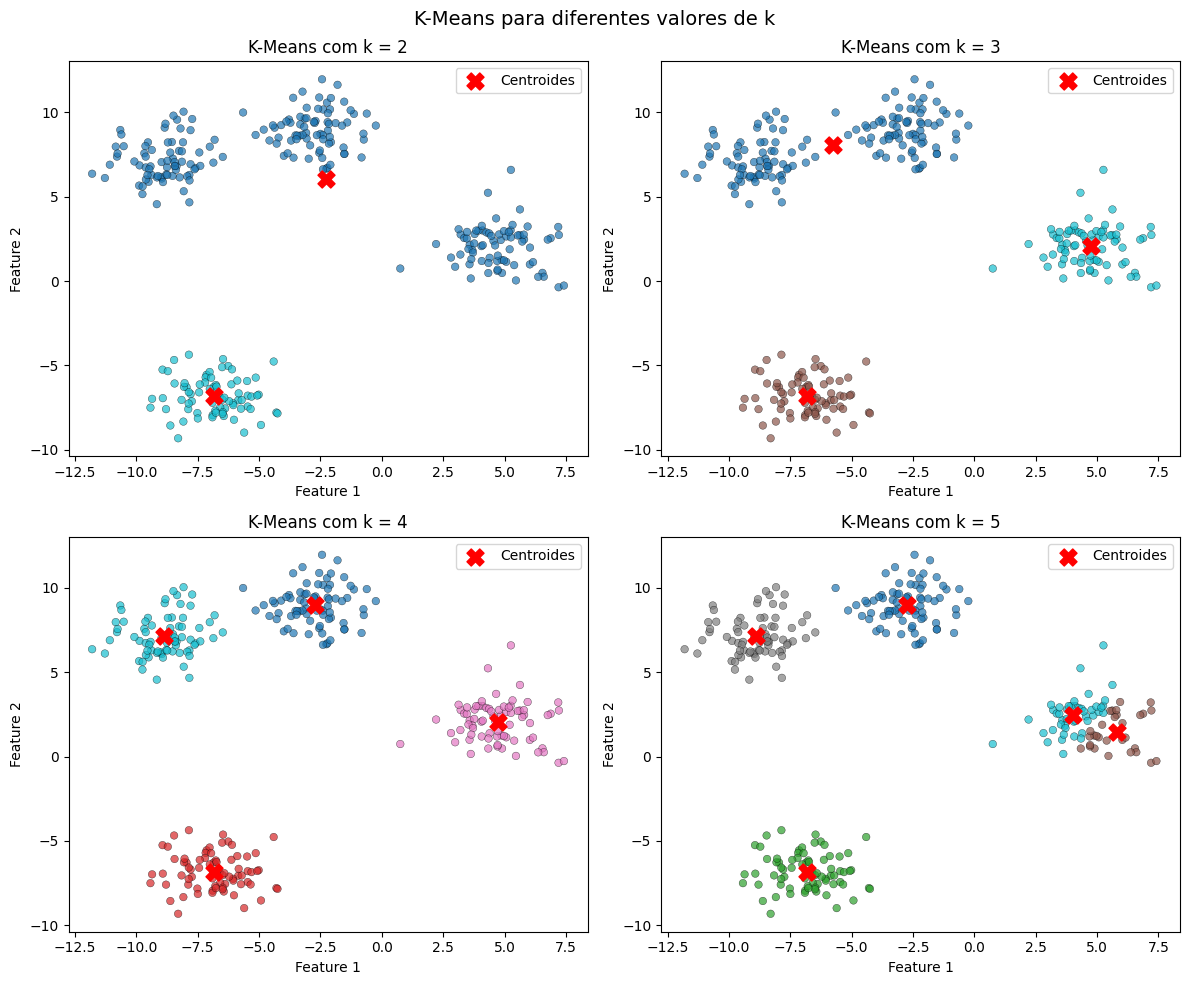

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
k_values = [2, 3, 4, 5]

for ax, k in zip(axes.flatten(), k_values):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', marker='X', s=150, zorder=5, label='Centroides')
    ax.set_title(f"K-Means com k = {k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()

plt.suptitle("K-Means para diferentes valores de k", fontsize=14)
plt.tight_layout()
plt.show()

### c) Comparação visual dos resultados

- **k=2:** Os dados são divididos de forma grosseira, agrupando clusters naturais que não deveriam estar juntos.
- **k=3:** Melhora, mas ainda agrupa pontos de regiões distintas.
- **k=4:** Separação coerente com a distribuição visual dos dados — clusters bem definidos e centroides posicionados de forma representativa.
- **k=5:** Um cluster natural é dividido artificialmente, introduzindo uma separação desnecessária.

### d) Método do Cotovelo (Elbow Method)

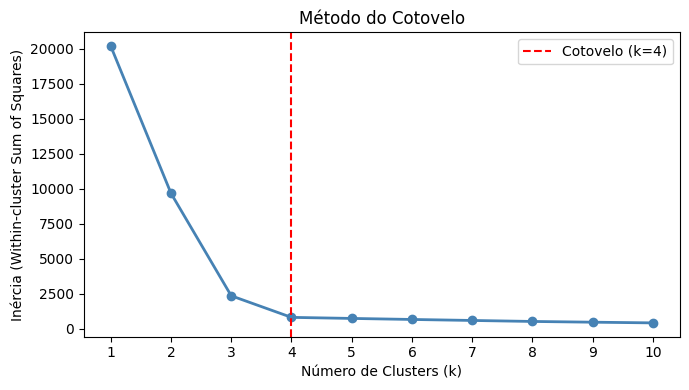

In [4]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='Cotovelo (k=4)')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia (Within-cluster Sum of Squares)")
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

### e) Identificação do valor ideal de k

No gráfico do cotovelo, a queda da inércia é acentuada até **k=4**, ponto em que a curva muda de inclinação de forma clara — caracterizando o "cotovelo". A partir de k=5, a redução da inércia se torna marginal, indicando que adicionar mais clusters não traz ganho significativo na coesão interna.

**Conclusão: o valor ideal de k é 4.**

### f) Comparação com o número real de clusters

O dataset foi gerado com `centers=4`, ou seja, **4 clusters reais**. O método do cotovelo identificou corretamente **k=4** como o valor ideal, confirmando a consistência do método neste cenário com clusters bem separados e variância controlada (`cluster_std=1.2`).

Essa concordância demonstra que o Elbow Method é eficaz quando os clusters têm tamanho e densidade relativamente uniformes, como é o caso dos dados gerados pelo `make_blobs`.

## Parte 2 – Clusterização com K-Means em Dados Reais (Wine Dataset)

### Carregamento dos dados

In [7]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

wine = load_wine()
X = wine.data
y = wine.target

print(X.shape)
print(np.unique(y))
print(wine.feature_names)

(178, 13)
[0 1 2]
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### a) Análise Exploratória

In [8]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
print(df.describe().round(2))

       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34                  0.13             0.41   
25%         

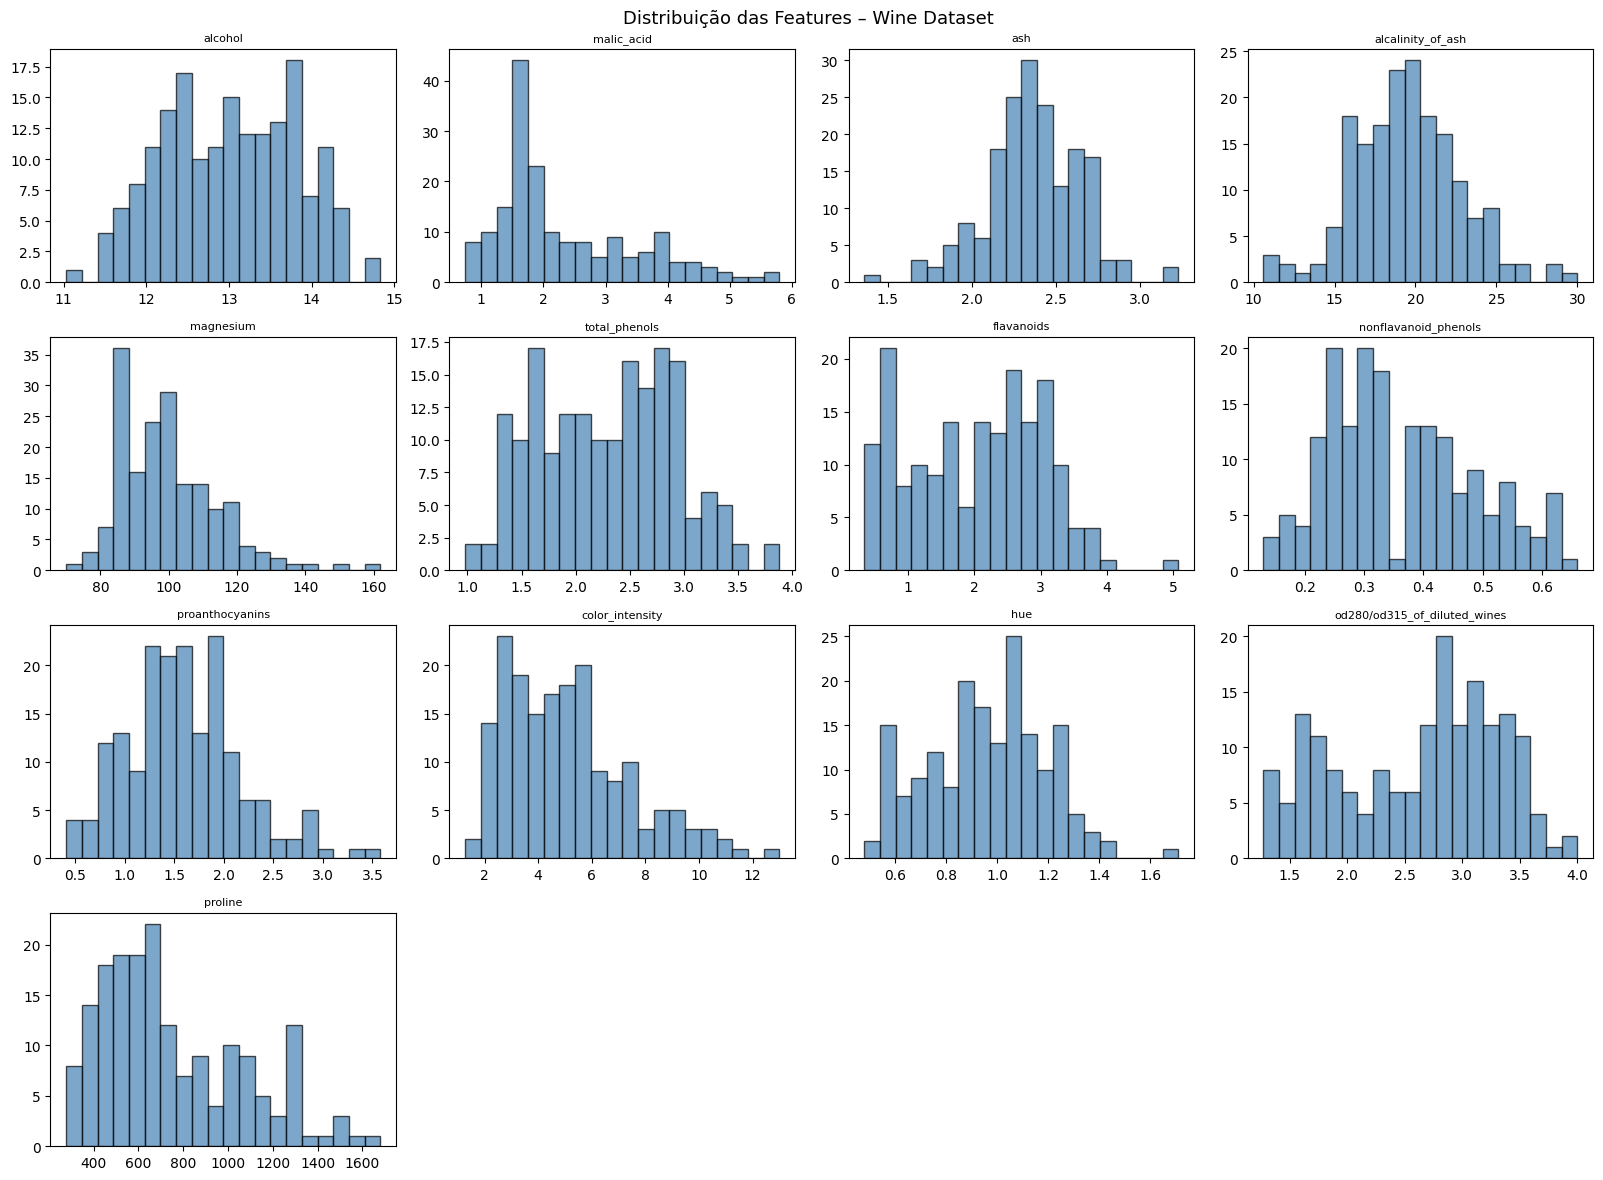

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, ax in enumerate(axes.flatten()):
    if i < X.shape[1]:
        ax.hist(X[:, i], bins=20, color='steelblue', edgecolor='k', alpha=0.7)
        ax.set_title(wine.feature_names[i], fontsize=8)
    else:
        ax.set_visible(False)
plt.suptitle("Distribuição das Features – Wine Dataset", fontsize=13)
plt.tight_layout()
plt.show()

### b) Padronização das variáveis

As features do Wine Dataset possuem escalas muito diferentes (ex: `proline` chega a ~1000, enquanto `ash` fica em torno de 2). O K-Means usa distância euclidiana, portanto é sensível a essa diferença de escala — features com valores maiores dominam o cálculo da distância. Por isso, aplicamos o **StandardScaler**, que transforma cada feature para média 0 e desvio padrão 1.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Média antes:", X[:, 0].mean().round(2), "| Média depois:", X_scaled[:, 0].mean().round(4))
print("Desvio antes:", X[:, 0].std().round(2), "| Desvio depois:", X_scaled[:, 0].std().round(4))

Média antes: 13.0 | Média depois: 0.0
Desvio antes: 0.81 | Desvio depois: 1.0


### c) Método do Cotovelo

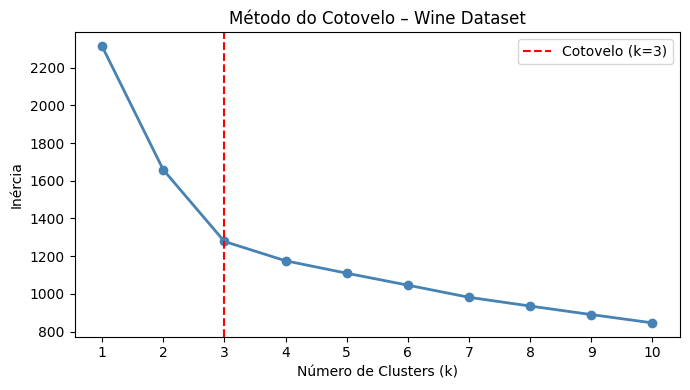

In [12]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='Cotovelo (k=3)')
plt.title("Método do Cotovelo – Wine Dataset")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia")
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

### d) Ajuste do K-Means com k=3

In [13]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)
print("Distribuição dos clusters encontrados:")
print(pd.Series(labels).value_counts().sort_index())

Distribuição dos clusters encontrados:
0    65
1    51
2    62
Name: count, dtype: int64


### e) Visualização 2D com PCA e 3D

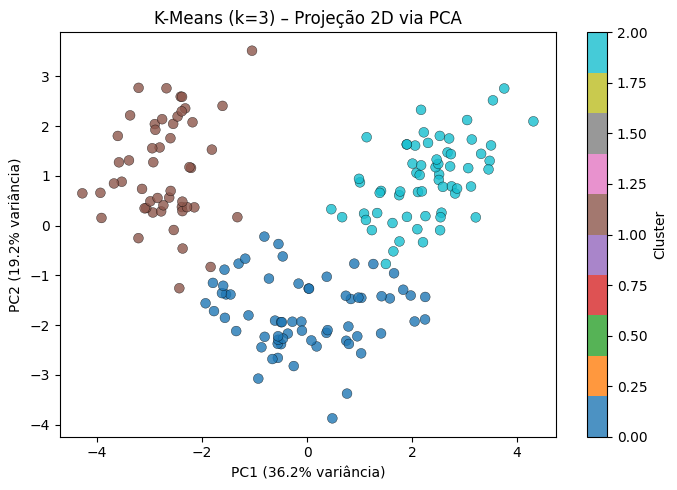

In [14]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels, cmap='tab10',
                      s=50, alpha=0.8, edgecolors='k', linewidths=0.3)
plt.title("K-Means (k=3) – Projeção 2D via PCA")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variância)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variância)")
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

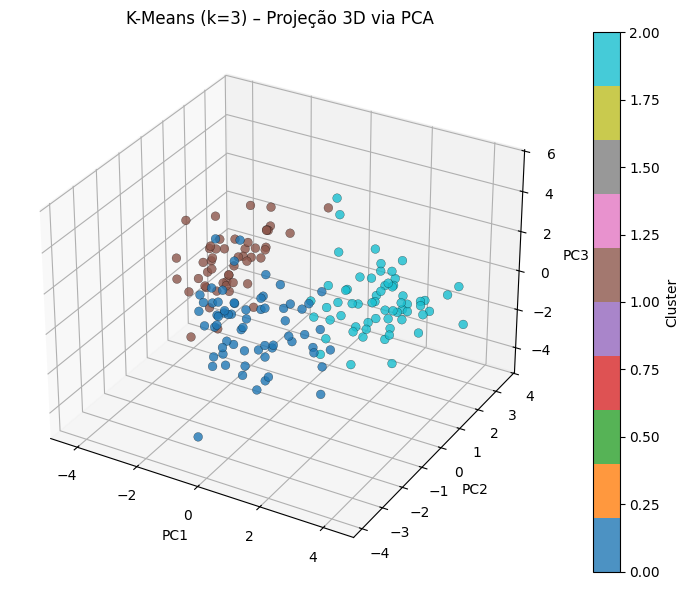

In [15]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
                c=labels, cmap='tab10', s=40, alpha=0.8, edgecolors='k', linewidths=0.2)
ax.set_title("K-Means (k=3) – Projeção 3D via PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(sc, label='Cluster')
plt.tight_layout()
plt.show()

### f) Comparação com as classes reais – Tabela Cruzada

In [16]:
crosstab = pd.crosstab(labels, y,
                       rownames=['Cluster K-Means'],
                       colnames=['Classe Real'])
print(crosstab)

Classe Real       0   1   2
Cluster K-Means            
0                 0  65   0
1                 0   3  48
2                59   3   0


### g) Discussão dos Resultados

O K-Means com k=3 produziu clusters coerentes com as 3 classes reais do Wine Dataset. A tabela cruzada mostra que, em grande parte, cada cluster corresponde predominantemente a uma classe real, evidenciando que as features químicas do vinho têm poder discriminativo.

Pontos de atenção:

- **K-Means é não supervisionado**: ele não conhece os rótulos reais, então a numeração dos clusters não precisa coincidir com a das classes — mas a correspondência estrutural é clara.
- **Padronização foi essencial**: sem o StandardScaler, features de escala maior (como `proline`) dominariam o agrupamento, distorcendo os clusters.
- **PCA como visualização**: a projeção em 2D e 3D facilita a interpretação, mas representa apenas uma parte da variância total dos dados.
- **Limitação do K-Means**: o algoritmo assume clusters esféricos e de tamanho similar, o que pode não capturar perfeitamente fronteiras mais complexas.